# **Practice 22 - Simulation-based Inference - Bootstrapping**

#### **Kelani Guyton**

---

**IMPORTANT**:
- Before starting the lab, save a copy to your google drive by navigating to `File > Save a copy in Drive` <br>

<br>


**Instructions**: Complete the lab below.

- <font color=red>Tasks</font> indicated in red must be completed to receive credit
- Include all code for your work
- Include markdown cells with written answers explaining your work when prompted
- **NOTE: Your completed lab must be submitted to Canvas as a .ipynb file by the end of the lab session**
---

<br>

####<font color=red>Organized</font>

**Answers should be organized in the following format for organization and readability**


<font color=red>Example task 1</font>

In [ ]:
# 1.

# This will be the code block to answer the first part of a task

1. This will be the text answer/explanation (if prompted) for the first task

<font color=red>Example task 2</font>

In [ ]:
# 2.

# This will be the code block to answer the second part of a task

2. This will be the text answer/explanation (if prompted) for the second task

<br>

Continue this format for the remaining subtasks


<br>

---

<br>

#### Packages

In [1]:
# install packages
install.packages("dslabs")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
# load libraries
library(dslabs)
library(ggplot2)

<br>

<br>

<br>

---

####<font color=red>Task 1</font>

<font color=red>Task 1.1</font>

We will be working with the `gapminder` dataset from the `dslabs` package.

* Show the first few lines of the `gapminder` dataset

In [5]:
head(dslabs::gapminder)

,country,year,infant_mortality,life_expectancy,fertility,population,gdp,continent,region
,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
1,Albania,1960,115.40,62.87,6.19,1636054,NA,Europe,Southern Europe
2,Algeria,1960,148.20,47.50,7.65,11124892,13828152297,Africa,Northern Africa
3,Angola,1960,208.00,35.98,7.32,5270844,NA,Africa,Middle Africa
4,Antigua and Barbuda,1960,NA,62.97,4.43,54681,NA,Americas,Caribbean
5,Argentina,1960,59.87,65.39,3.11,20619075,108322326649,Americas,South America
6,Armenia,1960,NA,66.86,4.55,1867396,NA,Asia,Western Asia


<br>

<font color=red>Task 1.2</font>

* Subset the `gapminder` dataset to only include the year `2010`

* Store the result as a new data frame called `gapminder2010`

* Use `unique()` to show the unique years in `gapminder2010` to verify your work

In [7]:
# subset

gapminder2010 <- gapminder[gapminder$year == 2010, ]

#checking with the unique
unique(gapminder2010$year)

[1] 2010

<br>

<font color=red>Task 1.3</font>

* Run the script below to remove missing values (`NA`) from the data frame

  `gapminder2010 <- na.omit(gapminder2010)`

In [8]:
gapminder2010 <- na.omit(gapminder2010)

<br>

<br>

<br>

---

####<font color=red>Task 2</font> - Confidence Interval of the Mean

<font color=red>Task 2.1</font>

* Calculate the average life expectancy across countries from the `gapminder2010` dataset

* Based on this average, are we able to say if the true average life expectancy across countries is greater than 70? Why/why not?

  Hint: The dataset is a sample from the population.

In [9]:
mean(gapminder2010$life_expectancy)

[1] 70.51561

No, we are unable to say if the population average is greater than 70 since 70. 5 is only the sample average. Sampling averages are subject to sampling variablility, and we would need to conduct a statistical test, such as using a confidence interval, to make this conclusion.

<br>

<font color=red>Task 2.2</font>

* Use bootstrapping with 2000 bootstrap samples to create a 95% confidence interval for the true average life expectancy across countries

In [12]:
# number fo boostrap sample
B <- 2000

# sample size
n <- nrow(gapminder2010)

# empty vector to store computed B bootstrap means
boot_means <- vector(length = B)

# loop to calculate the bootstrap means
for(i in 1:B) {

  # bootsrtapo sample of size n
  boot_samp <- sample(gapminder2010$life_expectancy, size = n, replace = TRUE)

  # compute mean of single bootstrap sample
  boot_mean <- mean(boot_samp)

  # store the bootstrap mean
  boot_means[i] <- boot_mean
}

# compute the 95% confidence interval;
print(quantile(boot_means, probs = c(0.025, 0.975)))

    2.5%    97.5% 
69.11847 71.81922 


<br>

<font color=red>Task 2.3</font>

* Plot a histogram of all of your bootstrap means

* Explain this plot using the concept of a sampling distribution

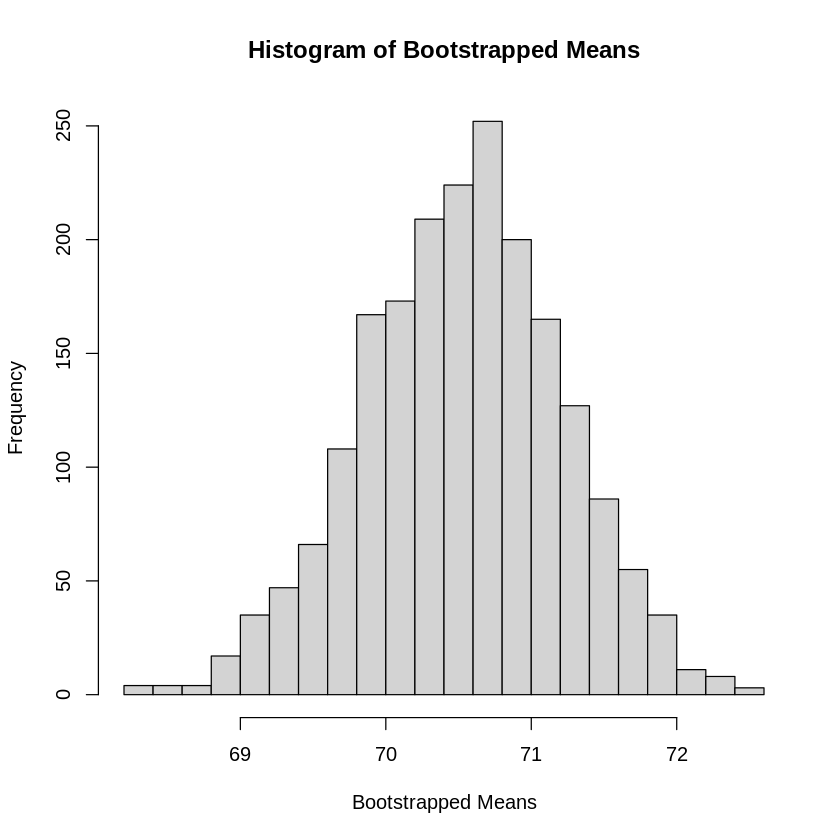

In [13]:
hist(boot_means,
      breaks = 30,
      main = "Histogram of Bootstrapped Means",
      xlab = "Bootstrapped Means" )

The sample mean can change from sample to sample. If we sample the population several times, we can observe the sampling distribution of the sample mean. However, in practice, we are unable to sample the population many times. The histogram above approximates the sampling distribution of the sample mean using bootstrapping.

<br>

<font color=red>Task 2.4</font>

* What is the interpretation of the 95% confidence interval from Task 2.2?

We are 95% confident that the true average life expectancy across countries is in the interval from task 2.2.

<br>

<font color=red>Task 2.5</font>

* Is the true average life expectancy across countries significantly different from 70 years?

* Is the true average life expectancy across countries significantly different from 68 years?

The true average life expectancy across countries is not significantly diffferent from 70 years since 70 is within our 95% confidence interval [,].

However, the true average life expectancy across countries is significantly greater than 68 years since 68 is below the lower bound of the 95% confidence interval.

<br>

<font color=red>Task 2.6</font>

* Create an 80% confidence interval for the true average life expectancy across countries.

  Hint: You don't need to perform the bootstrapping again! Only the quantile calculation.

* Is the 80% confidence interval narrow or wider than the 95% confidence interval? Why/why not? Explain your answer.

In [14]:
print(quantile(boot_means, probs = c(0.1, 0.9)))

     10%      90% 
69.65312 71.39618 


The 80% confidence interval is narrower than the 95% confidence interval. Since we require less confidence that the true average is within the bounds of the 80% interval, the interval does not need to be as wide.

<br>

<br>


---

####<font color=red>Task 3</font> - Confidence Interval of other Statistics

<font color=red>Task 3.1</font>

It turns out we can use bootstrapping to create confidence intervals for most other statistics!

* Use bootstrapping with 2000 bootstrap samples to create a 95% confidence interval for the true ***median*** life expectancy across countries

In [21]:
# number fo boostrap sample
B <- 2000

# sample size
n <- nrow(gapminder2010)

# empty vector to store computed B bootstrap medians
boot_meds <- vector(length = B)

# loop to calculate the bootstrap medians
for(i in 1:B) {

  # bootstrap sample of size n
  boot_samp <- sample(gapminder2010$life_expectancy, size = n, replace = TRUE)

  # compute median of single bootstrap sample
  boot_med <- median(boot_samp)

  # store the bootstrap median
  boot_meds[i] <- boot_med
}

# compute the 95% confidence interval;
print(quantile(boot_meds, probs = c(0.025, 0.975)))

 2.5% 97.5% 
 70.8  74.3 


<br>

<font color=red>Task 3.2</font>

* What is the interpretation of the 95% confidence interval from Task 3.1?

* Conduct a statistical test comparing the true median life expectancy across countries to a life expectancy of 70 years. What is your conclusion?

We are 95% confident that the true median life expectancy across countries is within our interval from task 3.1.

Since the lower bound of the confidence interval is greater than 70 (i.e. 70 not in our interval), we say the true median life expectancy across countries is significantly greater than 70 years old.

<br>

<font color=red>Task 3.3</font>

* Use bootstrapping with 2000 bootstrap samples to create a 95% confidence interval for the true ***standard deviation*** of life expectancy across countries

In [22]:
# number fo boostrap sample
B <- 2000

# sample size
n <- nrow(gapminder2010)

# empty vector to store computed B bootstrap sds
boot_sds <- vector(length = B)

# loop to calculate the bootstrap sds
for(i in 1:B) {

  # bootsrtapo sample of size n
  boot_samp <- sample(gapminder2010$life_expectancy, size = n, replace = TRUE)

  # compute mean of single bootstrap sample
  boot_sd <- sd(boot_samp)

  # store the bootstrap mean
  boot_sds[i] <- boot_sd
}

# compute the 95% confidence interval;
print(quantile(boot_sds, probs = c(0.025, 0.975)))

     2.5%     97.5% 
 7.932257 10.218425 


Since 10 is within my 95% confidence interval, the true standar deviation of life expectancy across countries is NOT significantly different from 10 years.

<br>

<font color=red>Task 3.4</font>

* Is the true standard deviation of life expectancy significantly greater than 10 years? What is your conclusion?

The true standard deviation of life expectancy is not significantly greater than 10 years. Although the upper bound is 10.2%, the lower bound is 7.9%.

<br>

<br>


---

####<font color=red>Task 4</font> - Confidence Intervals to Compare Statistics

We can also use boostrapping to create confidence intervals for the difference between statistics!

For example, comparing the means between groups.

<font color=red>Task 4.1</font>

* Using `ggplot`, plot a boxplot of life expectancy and continent

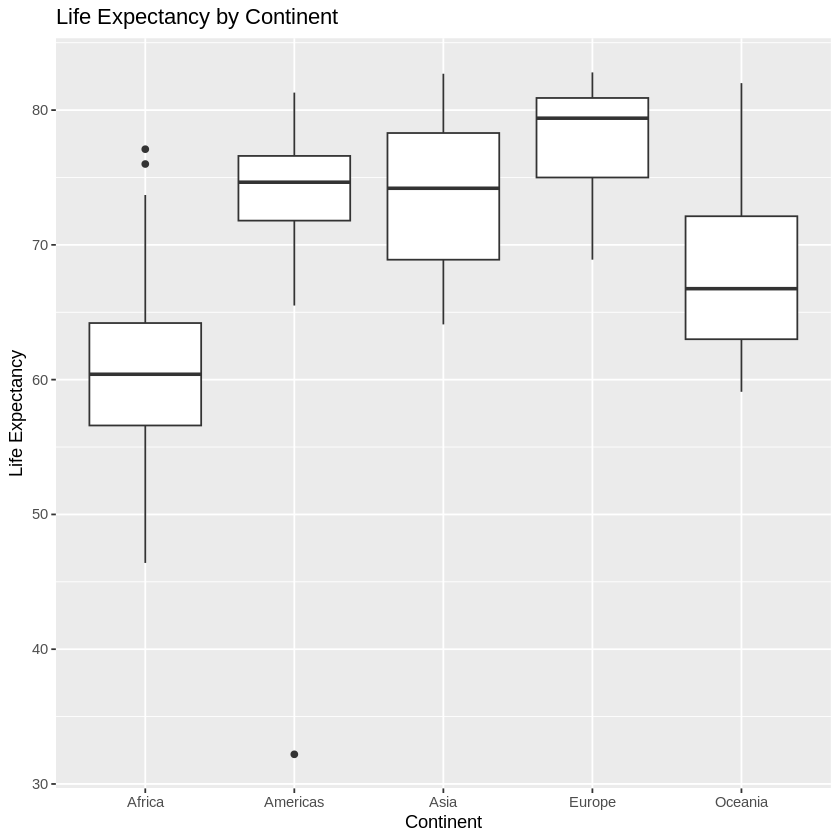

In [23]:
ggplot(data = gapminder2010, aes(x = continent, y = life_expectancy)) +
  geom_boxplot() +
  labs(title = "Life Expectancy by Continent",
  x = "Continent",
  y = "Life Expectancy")

<br>

<font color=red>Task 4.2</font>

* Using your boxplot from Task 4.1, ***visually*** compare the average life expectancy between

  *  Africa and Americas

  *  Americas and Asia

You should NOT use the word "significant" here since we are NOT performing a statistical test (yet)!

From the boxplot, it appears that the average life expectancy in Africa is lower than in the Americas. The aberage life expectancy appears similar between the Americas and Asia.

<br>

<font color=red>Task 4.3</font>

* Calculate the difference in mean life expectancy between

  * Africa and the Americas (should be 12.44)

  * Asia and the Americas (should be 0.05)

In [26]:
# subset life expectancy by continent
americas <- gapminder2010[gapminder2010$continent == "Americas", "life_expectancy"]
africa <- gapminder2010[gapminder2010$continent == "Africa", "life_expectancy"]
asia <- gapminder2010[gapminder2010$continent == "Asia", "life_expectancy"]

# calculate difference in mean
mean(americas) - mean(africa)
mean(americas) - mean(asia)

[1] 12.44165

[1] -0.0465843

<br>

<font color=red>Task 4.4</font>

* Use bootstrapping with 2000 bootstrap samples to create a 95% confidence interval for the difference in means between Africa and Americas.

  Hint: At each `for` loop iteration, calculate the difference between mean life expectancy in Americas and mean life expectancy in Africa. Part of what you need is shown below.

  ```
  # bootstrap sample of size n
  boot_ind  <- sample(1:nrow(gapminder2010), size = n, replace = TRUE)
  boot_samp <- gapminder2010[boot_ind,]

  # subset life expectancies for africa
  africa    <- boot_samp[boot_samp$continent == "Africa", "life_expectancy"]
# subset life expectancies for americas
americas  <- boot_samp[boot_samp$continent == "Americas", "life_expectancy"]

  # compute mean difference of single bootstrap sample
  boot_stat <- mean(americas) - mean(africa)
  ```

In [28]:
# nnumber of boostrap samples
B <- 2000

# sample size
n <- nrow(gapminder2010)

# vector to store computed difference in means
boot_stats <- vector(length = B)

# loop to calculate many bootstrap sample mean difference
for( i in 1:B) {

# bootstrap sample of size n
boot_ind  <- sample(1:nrow(gapminder2010), size = n, replace = TRUE)
boot_samp <- gapminder2010[boot_ind,]

# subset life expectancies for africa
africa    <- boot_samp[boot_samp$continent == "Africa", "life_expectancy"]
# subset life expectancies for americas
americas  <- boot_samp[boot_samp$continent == "Americas", "life_expectancy"]

# compute mean difference of single bootstrap sample
boot_stat <- mean(americas) - mean(africa)

# store the bootstrap mean
boot_stats[i] <- boot_stat

}

# compute the 95% confidence interval
print(quantile(boot_stats, probs = c(0.025, 0.975)))

    2.5%    97.5% 
 8.57614 15.41786 


<br>

<font color=red>Task 4.5</font>

* Use bootstrapping with 2000 bootstrap samples to create a 95% confidence interval for the difference in means between Asia and Americas.

In [29]:
# nnumber of boostrap samples
B <- 2000

# sample size
n <- nrow(gapminder2010)

# vector to store computed difference in means
boot_stats <- vector(length = B)

# loop to calculate many bootstrap sample mean difference
for( i in 1:B) {

# bootstrap sample of size n
boot_ind  <- sample(1:nrow(gapminder2010), size = n, replace = TRUE)
boot_samp <- gapminder2010[boot_ind,]

# subset life expectancies for africa
asia    <- boot_samp[boot_samp$continent == "Asia", "life_expectancy"]
# subset life expectancies for americas
americas  <- boot_samp[boot_samp$continent == "Americas", "life_expectancy"]

# compute mean difference of single bootstrap sample
boot_stat <- mean(americas) - mean(asia)

# store the bootstrap mean
boot_stats[i] <- boot_stat

}

# compute the 95% confidence interval
print(quantile(boot_stats, probs = c(0.025, 0.975)))

     2.5%     97.5% 
-3.627133  2.668398 


<br>

<font color=red>Task 4.6</font>

* Is the average life expectancy in the Americas significantly different than the average life expectancy in ***Africa***? Explain using your bootstrap confidence interval

* Is the average life expectancy in the Americas significantly different than the average life expectancy in ***Asia***? Explain using your bootstrap confidence interval

* Do your conclusions agree with your visual assessment from the boxplot in Task 4.1?

The average life expectancy in the Americas is significantly higher than the average life expectancy in Africa. The 95% bootstrap is 8.58 to 15.41.

The average life expectancy in the Americas is not significantly higher than the average life expectancy in Asia. The 95% boostrap is -3.63 to 2.67.

Yes, my conclusion agrees with my visual assessment from the boxplot in Task 4.1.